# Tienda online de videojuegos


## Preparar datos

Se cargan la librerias

In [2]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt
from scipy import stats as st
import seaborn as sns

Leer archivo del dataset "games.csv".

In [7]:
df_games = pd.read_csv("F:/Users/Luis Alberto/Documents/DATA SCIENCE/Tienda de videojuegos/games.csv")

Explorar información del dataset.

In [8]:
df_games.info()

print(df_games.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB
                        Name Platform  Year_of_Release         Genre  \
0                 Wii Sports      Wii           2006.0        Sports   
1          Super Mario Bros.      NES           1985.0      Platform   
2             Mario Kart Wii      Wii   




Se reemplazan los nombres de las columnas por minúsculas. 

In [9]:
new_name_columns = []

for old_name in df_games.columns:
    name_lower = old_name.lower()
    new_name_columns.append(name_lower)
    
df_games.columns = new_name_columns

print(df_games.columns)


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')


Se realiza limpieza de datos.

- Se eliminan las filas con datos ausentes para las columnas “name” y “year_of_release” debido a que los datos ausentes son muy pocos (menores al 5% del total de los datos.
- Se modifica el tipo de dato de la columna "year_of_release" para que sea de tipo entero y quitar el punto decimal.
- Para las columnas “critic_score” y “user_score” se utiliza la mediana para rellenar los valores ausentes. La mediana es mejor que la media porque no se ve afectada por juegos extremadamente malos o buenos.
- En la columna rating únicamente rellenamos los valores ausentes con el texto "Unknown" para no afectar los datos.

¿Por qué crees que los valores están ausentes?

Revisando brevemente los datos nos damos cuenta de que la mayoría de las filas que contienen datos ausentes son juegos qué se lanzaron antes del año 2000 donde probablemente no existía una plataforma o un concentrado de datos Donde se guardarán las calificaciones a los videojuegos.

NOTA:

Para poder modificar el tipo de datos de la columna “user_score” se utiliza el método to_numeric utilizando el atributo “coerce” para poder reemplazar los valores que contienen tbd por NaN y eliminar las cadenas de texto.

In [10]:
# Se eliminan las filas con datos ausentes para las columnas “name” y “year_of_release”
df_games = df_games.dropna(subset = ["name", "year_of_release"]).reset_index(drop=True)

# Se modifica el tipo de dato
df_games["year_of_release"] = df_games["year_of_release"].astype("int")

# Se rellenan datos ausentes con la mediana
critic_score_median = df_games["critic_score"].median()
df_games["critic_score"] = df_games["critic_score"].fillna(critic_score_median)

# Se rellenan datos ausentes con la mediana
df_games["user_score"] = pd.to_numeric(df_games["user_score"], errors = "coerce")
user_score_median = df_games["user_score"].median()
df_games["user_score"] = df_games["user_score"].fillna(user_score_median)

# Se rellenan datos ausentes con el texto "Unknown"
df_games["rating"] = df_games["rating"].fillna("Unknown")

df_games.info()

<class 'pandas.DataFrame'>
RangeIndex: 16444 entries, 0 to 16443
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  str    
 1   platform         16444 non-null  str    
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  str    
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     16444 non-null  float64
 9   user_score       16444 non-null  float64
 10  rating           16444 non-null  str    
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


Se realiza la suma de las ventas totales en todas las regiones por cada videojuego y se coloca esta información en una columna nueva “total_sales”.

In [11]:

df_games["total_sales"] = df_games["na_sales"] + df_games["eu_sales"] + df_games["jp_sales"] + df_games["other_sales"]
print(df_games.head(5))


                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score   rating  \
0     28.96      3.77         8.45          76.0         8.0        E   
1      3.58      6.81         0.77          71.0         7.5  Unknown   
2     12.76      3.79         3.29          82.0         8.3        E   
3     10.93      3.28         2.95          80.0         8.0        E   
4      8.89     10.22         1.00          71.0         7.5  Unknown   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3     

## Analisis de datos

Primero, vamos a ver cuántos juegos se lanzaron por año por medio de un gráfico de barras.

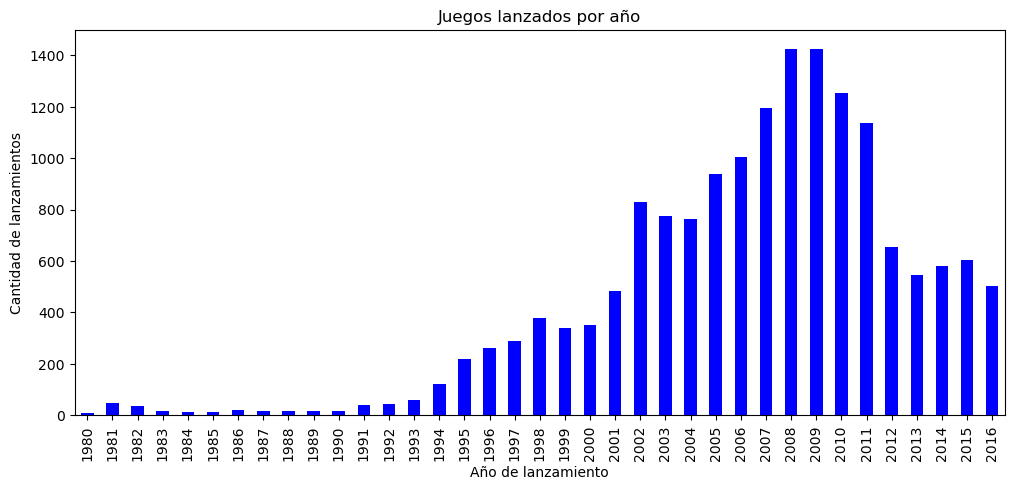

In [12]:
# Se agrupan los datos por año de lanzamiento
games_per_year = df_games.groupby("year_of_release")["name"].count()
games_per_year.plot(kind="bar", figsize=(12, 5), title="Juegos lanzados por año", ylabel="Cantidad de lanzamientos", xlabel="Año de lanzamiento", color="blue")
plt.show()

##### Conclusión grafico:
Antes de los años 90 hay pocos datos. Los periodos más significativos suelen ser del 2000 en adelante.

#### Plataformas con mayores ventas

Ahora vamos a ver que plataformas tuvieron mayores ventas totales a lo largo de los años.

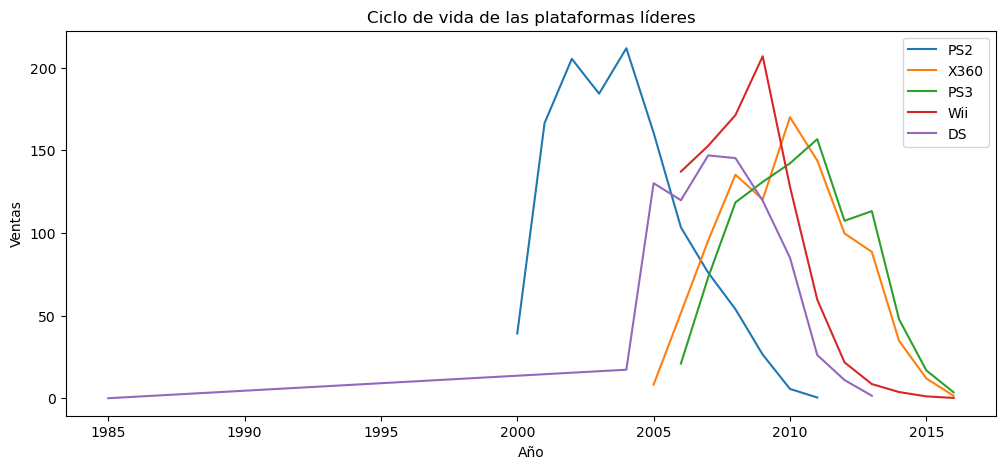

In [14]:
# Se agrupan los datos por plataforma y se suman las ventas totales
platform_sales = df_games.groupby("platform")["total_sales"].sum().sort_values(ascending=False)
top_platforms = platform_sales.head(5).index

# Se grafica la distribución de ventas anuales para el top 5
for p in top_platforms:
    df_games[df_games["platform"] == p].groupby("year_of_release")["total_sales"].sum().plot(label=p, figsize=(12, 5))

plt.title("Ciclo de vida de las plataformas líderes")
plt.legend()
plt.xlabel("Año")
plt.ylabel("Ventas")
plt.show()


##### Conclusión grafico:
Las plataformas suelen durar entre 7 y 10 años antes de que sus ventas caigan a cero y desaparezcan. Las plataformas con mayores ventas son PS2 y Xbox360.

#### Determinar el período para el modelo 2017

Para construir un modelo para 2017, no nos sirven datos de 1995. Se usan datos de 2013 o 2014 en adelante que es cuando aparecen PS4 y Xbox One.

In [17]:
# Filtramos para quedarnos solo con datos recientes (periodo relevante)
df_recent = df_games.query('year_of_release >= 2014').reset_index(drop=True)
platform_sales_recent = df_recent.groupby("platform")["total_sales"].sum().sort_values(ascending=False)

print(platform_sales_recent)

platform
PS4     288.15
XOne    140.36
3DS      86.68
PS3      68.18
X360     48.22
WiiU     42.98
PC       27.05
PSV      22.40
Wii       5.07
PSP       0.36
Name: total_sales, dtype: float64


A partir del 2013 las plataformas con mayores ventas son PS4 y xbox one.

#### Diagramas de caja

Creamos un diagrama de caja para revisar si las diferencias en ventas son significativas.

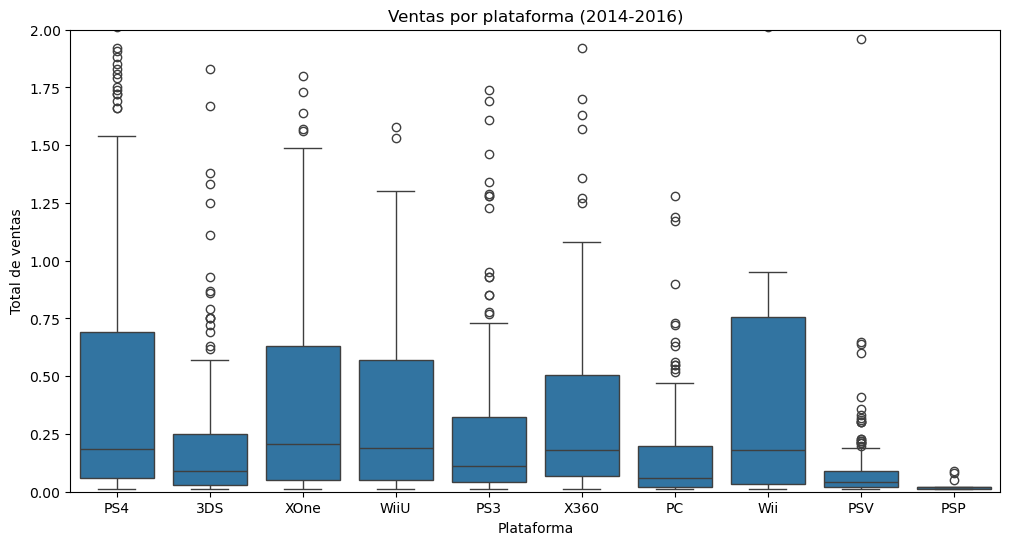

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_recent, x = "platform", y = "total_sales")
plt.ylim(0, 2)
plt.title("Ventas por plataforma (2014-2016)")
plt.xlabel("Plataforma")
plt.ylabel("Total de ventas")
plt.show()

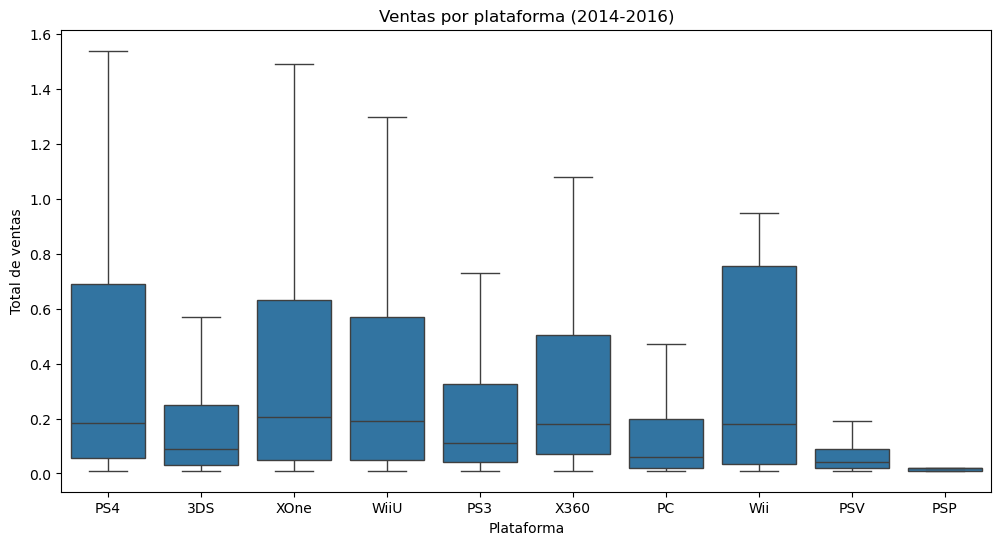

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_recent, x = "platform", y = "total_sales", showfliers = False)
#plt.ylim(0, 2) # <- ya no lo necesitamos
plt.title("Ventas por plataforma (2014-2016)")
plt.xlabel("Plataforma")
plt.ylabel("Total de ventas")
plt.show()

Se puede observar que las consolas PS4, XOne, WiiU y X360 tienen cajas más grandes y bigotes más largos en comparación con las portátiles (PSV, PSP) o la PC. Esto indica que estas plataformas manejan un volumen de ventas por título mucho mayor.

Aunque PS4 es la plataforma con los éxitos más grandes, las plataformas como Xbox One y Wii U muestran distribuciones de ventas promedio muy competitivas.

#### Gráfico de dispersión

Generamos gráficos de dispersión para observar cómo afectan las reseñas de los usuarios y de los profesionales las ventas de la plataforma PS4.

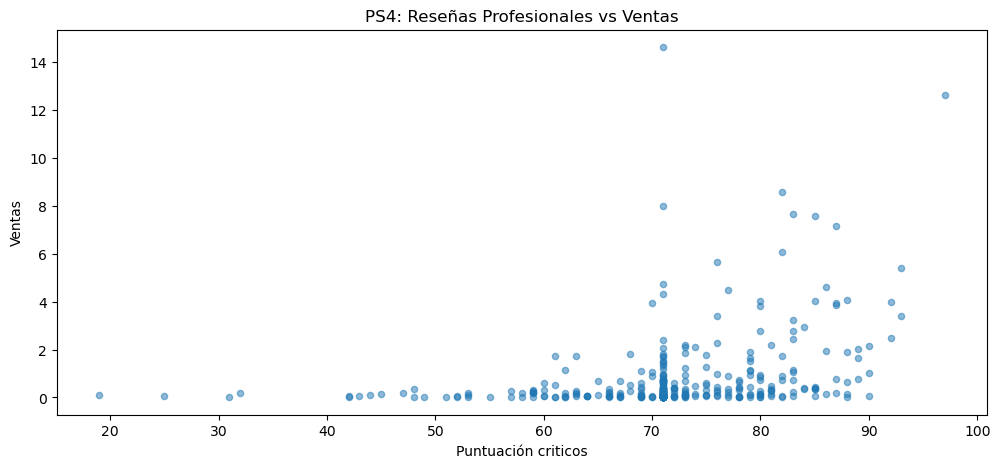

Correlación reseñas profesionales:  0.33361472751696886


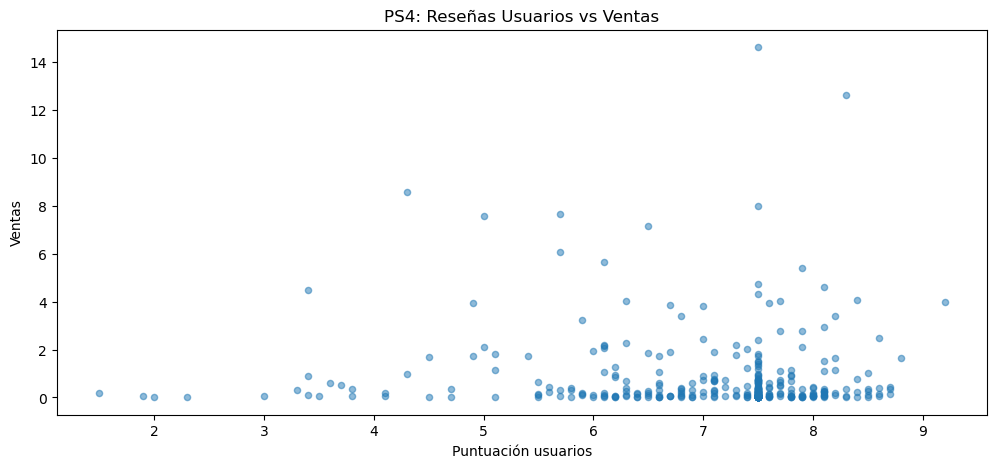

Correlación reseñas usuarios:  -0.06407535236901882


In [20]:
# Filtramos los datos
ps4_data = df_recent[df_recent["platform"] == "PS4"]


# Generamos el diagrama de dispersión y calculamos la correlación para las reseñas de los profesionales.
ps4_data.plot(kind="scatter", x="critic_score", y="total_sales", alpha=0.5, title="PS4: Reseñas Profesionales vs Ventas", figsize=(12, 5), 
             xlabel="Puntuación criticos", ylabel="Ventas")
plt.show()
print("Correlación reseñas profesionales: ", ps4_data["critic_score"].corr(ps4_data["total_sales"]))

# Generamos el diagrama de dispersión y calculamos la correlación para las reseñas de los usuarios.
ps4_data.plot(kind="scatter", x="user_score", y="total_sales", alpha=0.5, title="PS4: Reseñas Usuarios vs Ventas", figsize=(12, 5), 
             xlabel="Puntuación usuarios", ylabel="Ventas")
plt.show()
print("Correlación reseñas usuarios: ", ps4_data["user_score"].corr(ps4_data["total_sales"]))


Reseñas Profesionales vs Ventas
En el primer diagrama de dispersión observamos que a medida que aumenta la puntuación de los críticos las ventas tienden a subir, la mayoría de los juegos con ventas altas se concentran en un rango de calificación de 70 a 90 puntos esto nos indica que una buena reseña profesional es un indicador de que un juego tendrá éxito.

Reseñas Usuarios vs Ventas
Para el segundo diagrama de dispersión se obtiene una correlación ligeramente negativa pero se muestran puntos de forma extendida horizontalmente sin una dirección clara, por lo que las ventas de PS4 no dependen de la opinión del público en general.


#### Gráfico de distribución por géneros

Generamos un gráfico de barras para observar la distribución general de las ventas de los videojuegos por género.

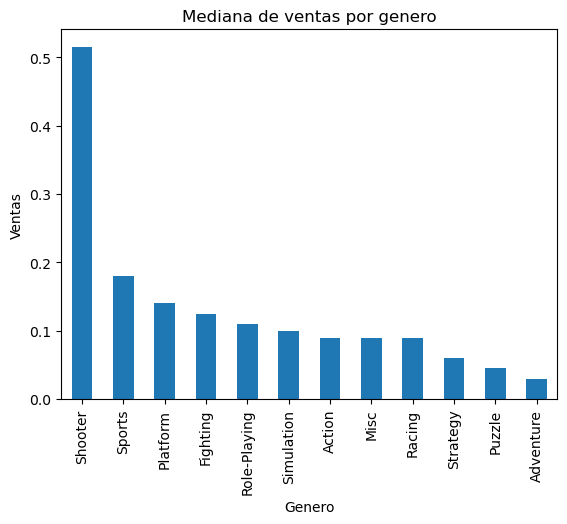

In [21]:

genre_sales = df_recent.groupby("genre")["total_sales"].median().sort_values(ascending=False)
genre_sales.plot(kind="bar", title="Mediana de ventas por genero", ylabel="Ventas", xlabel="Genero")

plt.show()

En el gráfico observamos qué destaca mayormente el género shooter, seguido de los videojuegos sports, con esto podemos dar una aproximación de lo que será el comportamiento de las ventas de videojuegos para el año 2017

#### Ventas por Región 
Se agrupan los datos por plataforma para analizar las ventas en las diferentes regiones.

In [22]:
regions = ["na_sales", "eu_sales", "jp_sales", "other_sales"]

for region in regions:


    top_platforms = df_recent.groupby("platform")[region].sum().sort_values(ascending=False).head(5)
    print(f"Top 5 plataformas en {region.upper()}:")
    print(top_platforms)
    print(" ")


Top 5 plataformas en NA_SALES:
platform
PS4     98.61
XOne    81.27
X360    28.30
3DS     22.64
PS3     22.05
Name: na_sales, dtype: float64
 
Top 5 plataformas en EU_SALES:
platform
PS4     130.04
XOne     46.25
PS3      25.54
PC       17.97
3DS      16.12
Name: eu_sales, dtype: float64
 
Top 5 plataformas en JP_SALES:
platform
3DS     44.24
PS4     15.02
PSV     14.54
PS3     11.22
WiiU     7.31
Name: jp_sales, dtype: float64
 
Top 5 plataformas en OTHER_SALES:
platform
PS4     44.48
XOne    12.52
PS3      9.37
X360     4.35
3DS      3.68
Name: other_sales, dtype: float64
 


JP es la única región en donde los videojuegos de la plataforma PS4 no son los más populares. A nivel global PS4 y XOne son las plataformas con mayores ventas. En la región de EU fue donde los videojuegos de PS4 tuvieron mayores ventas.

In [23]:
for region in regions:
    top_genres = df_recent.groupby("genre")[region].sum().sort_values(ascending=False).head(5)
    print(f"Top 5 generos en {region.upper()}:")
    print(top_genres)


Top 5 generos en NA_SALES:
genre
Shooter         79.02
Action          72.53
Sports          46.13
Role-Playing    33.47
Misc            15.05
Name: na_sales, dtype: float64
Top 5 generos en EU_SALES:
genre
Action          74.68
Shooter         65.52
Sports          45.73
Role-Playing    28.17
Racing          14.13
Name: eu_sales, dtype: float64
Top 5 generos en JP_SALES:
genre
Role-Playing    31.16
Action          29.58
Fighting         6.37
Misc             5.61
Shooter          4.87
Name: jp_sales, dtype: float64
Top 5 generos en OTHER_SALES:
genre
Action          22.57
Shooter         21.53
Sports          14.36
Role-Playing     8.64
Misc             4.03
Name: other_sales, dtype: float64


Los géneros Action y shooter son los más venidos a nivel global, Nuevamente la región JP tiene un comportamiento diferente a las demás regiones, teniendo como genero con mayores ventas Role-Playing.

Ventas por rating en NA_SALES:
rating
M          96.42
Unknown    64.72
E          50.74
T          38.95
E10+       33.23
Name: na_sales, dtype: float64
Ventas por rating en EU_SALES:
rating
M          93.44
Unknown    58.95
E          58.06
T          34.07
E10+       26.16
Name: eu_sales, dtype: float64
Ventas por rating en JP_SALES:
rating
Unknown    56.90
T          14.78
E           8.94
M           8.01
E10+        4.46
Name: jp_sales, dtype: float64
Ventas por rating en OTHER_SALES:
rating
M          28.67
Unknown    18.40
E          15.39
T          11.33
E10+        7.83
Name: other_sales, dtype: float64


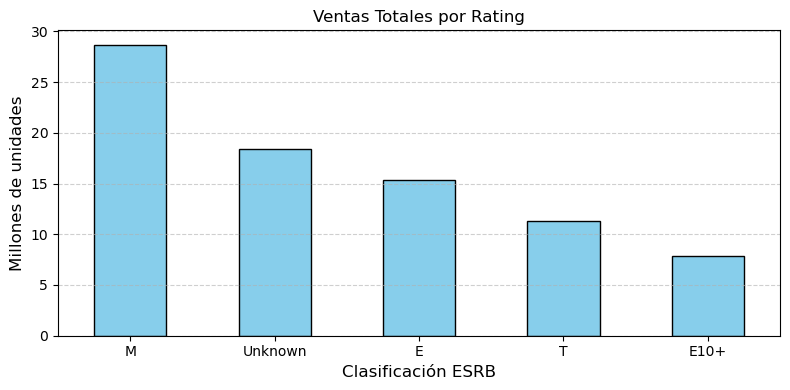

In [34]:
for region in regions:
    top_esrb = df_recent.groupby("rating")[region].sum().sort_values(ascending=False)
    print(f"Ventas por rating en {region.upper()}:")
    print(top_esrb)

plt.figure(figsize=(8, 4))

# Creamos el gráfico de barras directamente desde la serie de pandas
top_esrb.plot(kind='bar', color='skyblue', edgecolor='black')
    
    # Personalización
plt.title(f"Ventas Totales por Rating")
plt.xlabel("Clasificación ESRB", fontsize=12)
plt.ylabel("Millones de unidades", fontsize=12)
plt.xticks(rotation=0) # Mantiene las letras (M, E, T) derechas
plt.grid(axis='y', linestyle='--', alpha=0.6)
    
plt.tight_layout()

M es la clasificacion con mas ventas en todas las regiones.

#### Prueba de hipotesis

Hipótesis Nula: Los promedios de calificación de los usuarios para Xbox One y PC son iguales.

Hipótesis Alternativa: Los promedios son diferentes.


In [25]:
alpha = 0.05

xboxone_scores = df_recent.query("platform == 'XOne'")["user_score"]
pc_scores = df_recent.query("platform == 'PC'")["user_score"]

results = st.ttest_ind(xboxone_scores, pc_scores, equal_var=False)

print("Valor de p:", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


Valor de p: 0.04137423162201445
Rechazamos la hipótesis nula


Hipótesis Nula: Los promedios de calificación de usuarios para los géneros Acción y Deportes son iguales.

Hipótesis Alternativa: Los promedios son diferentes.


In [26]:
action_scores = df_recent.query("genre == 'Action'")["user_score"]
sports_scores = df_recent.query("genre == 'Sports'")["user_score"]

result = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print("Valor de p:", result.pvalue)

if result.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


Valor de p: 3.884930711015993e-17
Rechazamos la hipótesis nula


#### Conclusión general

Tras procesar y analizar los datos de más de 16,000 videojuegos, se han identificado patrones claros que definen el éxito en la industria. El análisis se centró en el periodo 2014-2016 para garantizar que las recomendaciones sean vigentes para el próximo año.

Las plataformas con mayor potencial de rentabilidad son PS4 y Xbox One, las cuales se encuentran en su fase de crecimiento. A pesar de no tener los picos de ventas de las consolas, el PC se mantiene como una plataforma constante y relevante para el mercado.

Se confirmó que las reseñas de los críticos profesionales tienen un impacto directo y positivo en las ventas. Las calificaciones de los usuarios no muestran una correlación significativa con el volumen de ventas.

En la primera prueba de hipótesis se rechazó la hipótesis nula (p-value = 0.041), lo que indica que las calificaciones promedio de los usuarios son diferentes entre estas plataformas en el periodo reciente. En la segunda prueba de hipótesis se obtuvo un p-value extremadamente bajo, rechazando contundentemente la hipótesis nula. Esto confirma que los usuarios perciben y califican de manera distinta estos géneros, siendo Acción el que goza de mejor recepción promedio.
